# D01 · The question is an estimand, not a button

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PD01](../../curriculum/papers/design.md#pd01).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** Which pipeline choices could change the scientific quantity being estimated rather than merely its estimator?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

An estimand states the quantity you intend to learn: the population, outcome, comparison, and averaging rule. “Find the region associated with memory” leaves all four open. “Average within-person change in a prespecified region's response under task A versus task B among eligible adults” is more precise. It still needs a measurement definition and a design that makes the comparison credible. Today you will distinguish a causal quantity from an association before asking AI for regression code.

Potential outcomes are a useful bookkeeping device. Each synthetic person has an outcome under no intervention, Y(0), and another under intervention, Y(1). Their difference is that person's intervention effect. In actual research we normally observe only one outcome under one assigned treatment at that time; the other is counterfactual. A simulation lets us reveal both, so we can test whether an analysis recovers the intended average. Knowing the simulated truth does not grant access to the missing counterfactual in a real dataset.

Our population has two baseline strata with equally many people. The intervention effect is 0.3 in one stratum and 0.7 in the other. The average treatment effect is therefore 0.5 outcome units. We compare an observational allocation that treats only high-baseline people with a balanced allocation that includes treated and untreated people in both strata. The observed-group contrast can be far from the average effect even though every number is measured correctly.

The transformation is potential outcomes plus an assignment rule → observed outcomes → a group contrast. Assignment changes which outcome is visible, not the underlying potential outcomes. Random assignment protects the comparison in expectation; our exact within-stratum balance deliberately eliminates random imbalance so the arithmetic is inspectable. In a finite randomized trial, estimation noise remains. Consistency, meaningful interventions, positivity, and no interference are additional substantive assumptions. A diagnosis or age group is not an intervention simply because a column is named treatment.

Predict the average causal effect and the observational group difference. Which missing comparison makes adjustment impossible in the observational allocation?

Target / observational / balanced: 0.49999999999999994 6.7 0.5000000000000001


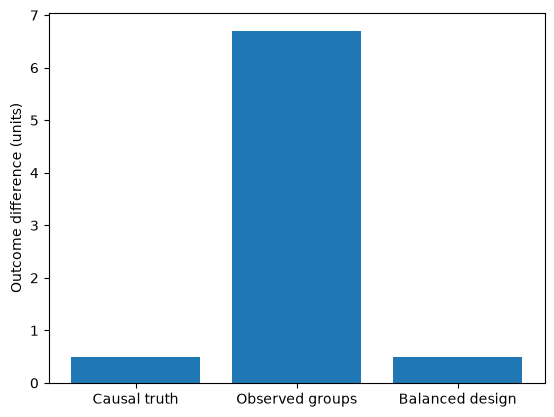

In [1]:
import numpy as np
import matplotlib.pyplot as plt
x = np.repeat([-1., 1.], 100)
y0 = 3 * x
effect = 0.5 + 0.2 * x
y1 = y0 + effect
observational = (x > 0).astype(int)
balanced = np.tile([0, 1], 100)
def observed_contrast(assignment):
    y = np.where(assignment == 1, y1, y0)
    return y[assignment == 1].mean() - y[assignment == 0].mean()
truth = effect.mean()
wrong = observed_contrast(observational)
controlled = observed_contrast(balanced)
assert np.allclose([truth, wrong, controlled], [0.5, 6.7, 0.5])
print('Target / observational / balanced:', truth, wrong, controlled)
plt.bar(['Causal truth', 'Observed groups', 'Balanced design'], [truth, wrong, controlled])
plt.ylabel('Outcome difference (units)'); plt.show()

Now change the target population rather than the observed sample. A population with 80% high-baseline people has another average effect even under an identical intervention.

In [2]:
target_weights = np.where(x > 0, 0.8 / 100, 0.2 / 100)
target_effect = target_weights @ effect
assert np.isclose(target_weights.sum(), 1)
assert np.isclose(target_effect, 0.62)
print('Equal-stratum target:', truth, '80%-high-stratum target:', target_effect)
assert np.linalg.matrix_rank(np.column_stack([np.ones(200), observational, x])) == 2
print('Site/stratum and assignment cannot be separated under this allocation.')

Equal-stratum target: 0.49999999999999994 80%-high-stratum target: 0.6199999999999999
Site/stratum and assignment cannot be separated under this allocation.


## Supervise the AI, then transfer the idea

**AI prompt:** “Name the estimand, intervention, comparison population, and unit in this notebook. Explain why 6.7 and 0.5 differ. Propose at most 15 lines to estimate the effect after a balanced assignment. Before code, ask me which potential outcomes a real study observes. Do not convert an observational association into a causal claim.”

**Deliberate mistake:** ask the tutor to adjust away the observational imbalance using both treatment and stratum. The matrix is rank deficient, so successful numerical fitting does not identify separate effects. Repair the design or narrow the claim. In a real task-fMRI project, document randomization, order, carryover, compliance, and the target contrast. A contrast between diagnostic groups usually supports an association unless additional causal assumptions and a defensible intervention are specified. Deliver two estimand sentences with different target-population weights and explain why their answers can differ without either calculation being wrong.

## Answer key — read after your own explanation

The population average effect is 0.5, the confounded observed-group difference is 6.7, and the balanced contrast is 0.5. An 80%-high-stratum population has effect 0.62. The observational allocation has no untreated high-stratum or treated low-stratum people; adding covariate names cannot create those comparisons. Check yourself: changing the population weights changes the estimand; changing assignment changes identifiability. A randomized contrast is not guaranteed numerically equal to truth in every finite noisy sample.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [Hernán and Robins, author-hosted Causal Inference: What If](https://miguelhernan.org/whatifbook), chapters 1–3 for the framework; [MIT 9.63 actual lecture list](https://ocw.mit.edu/courses/9-63-laboratory-in-visual-cognition-fall-2009/pages/lecture-notes/), Variables and controls and Single factor design, for the course-level connection. See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Reopen [PD01](../../curriculum/papers/design.md#pd01) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
